# Notebook 2 — Approche semi-supervisée
## Projet BrainScanAI — détection de tumeurs cérébrales (CurelyticsIA)

Ce second livrable met en œuvre et **évalue** l'approche semi-supervisée, selon la méthode de l'énoncé :

1. **Modèle supervisé** : un CNN entraîné uniquement sur le jeu fortement labellisé.
2. **Modèle semi-supervisé** : le même CNN entraîné d'abord sur le jeu faiblement labellisé (pseudo-labels du Notebook 1), puis affiné sur le jeu fortement labellisé.
3. **Comparaison** des deux sur un jeu de test commun, jamais vu.

> Les jeux faible et fort restent **séparés** ; le jeu de test provient uniquement du jeu fort (seuls vrais labels disponibles).

## 4.1 — Chargement des jeux et préparation du jeu de test

On charge le jeu **faible** (pseudo-labels) et le jeu **fort** (vrais labels) produits au Notebook 1, puis on découpe le jeu fort en `train_fort` / `test_fort` (split **stratifié** = mêmes proportions de classes). **`test_fort` ne sert qu'à l'évaluation finale, identique pour les deux modèles.**

In [1]:
from pathlib import Path
import random
import numpy as np, pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def fixer_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

fixer_seed(0)

faible = pd.read_csv("../outputs/faiblement_labellise.csv")   # colonnes : chemin, pseudo_label
fort   = pd.read_csv("../outputs/fortement_labellise.csv")     # colonnes : chemin, label

train_fort, test_fort = train_test_split(
    fort, test_size=0.3, stratify=fort["label"], random_state=0)

print("faible :", len(faible), "| fort :", len(fort))
print("train_fort :", len(train_fort), "| test_fort :", len(test_fort))
print("test_fort par classe :\n", test_fort["label"].value_counts())

faible : 1183 | fort : 98
train_fort : 68 | test_fort : 30
test_fort par classe :
 label
normal    15
cancer    15
Name: count, dtype: int64


## 4.2 — Boîte à outils : Dataset, modèle, entraînement, évaluation

Des briques **réutilisables** pour les deux modèles : chargement des images, modèle ResNet18 (transfer learning), boucle d'entraînement, fonction d'évaluation.

In [2]:
CLASSES = {"normal": 0, "cancer": 1}   # cancer = 1 (classe positive = erreur coûteuse)

class IRMDataset(Dataset):
    def __init__(self, df, col_label, tf):
        self.chemins = df["chemin"].tolist()
        self.labels  = [CLASSES[l] for l in df[col_label]]
        self.tf = tf
    def __len__(self): return len(self.chemins)
    def __getitem__(self, i):
        img = Image.open(self.chemins[i]).convert("RGB")
        return self.tf(img), self.labels[i]

norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # stats ImageNet
tf_train = transforms.Compose([transforms.Resize((224, 224)),
                               transforms.RandomHorizontalFlip(),
                               transforms.ToTensor(), norm])
tf_eval  = transforms.Compose([transforms.Resize((224, 224)),
                               transforms.ToTensor(), norm])

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

def nouveau_modele():
    m = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    m.fc = torch.nn.Linear(m.fc.in_features, 2)   # nouvelle tête : 2 classes
    return m.to(device)

def entrainer(model, loader, epochs=5, lr=1e-4, verbose=True):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    perte = torch.nn.CrossEntropyLoss()
    model.train()
    for ep in range(epochs):
        cumul = 0
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            err = perte(model(X), y)
            err.backward(); opt.step()
            cumul += err.item()
        if verbose:
            print(f"  epoch {ep+1}/{epochs} — perte {cumul/len(loader):.3f}")
    return model

@torch.no_grad()
def evaluer(model, loader):
    model.eval()
    y_vrai, y_pred, y_proba = [], [], []
    for X, y in loader:
        proba = torch.softmax(model(X.to(device)), dim=1)[:, 1]   # proba classe cancer
        y_proba += proba.cpu().tolist()
        y_pred  += (proba > 0.5).int().cpu().tolist()
        y_vrai  += y.tolist()
    return np.array(y_vrai), np.array(y_pred), np.array(y_proba)

print("Device :", device)

Device : cuda


## 4.3 — Modèle A : supervisé (jeu fort uniquement)

Référence de comparaison : un modèle neuf entraîné **seulement** sur `train_fort`, puis évalué sur `test_fort`.

In [4]:
loader_train_fort = DataLoader(IRMDataset(train_fort, "label", tf_train), batch_size=16, shuffle=True)
loader_test       = DataLoader(IRMDataset(test_fort,  "label", tf_eval),  batch_size=16)

print("Entraînement du modèle A (supervisé) :")
model_A = entrainer(nouveau_modele(), loader_train_fort, epochs=5, lr=1e-4)
yA_vrai, yA_pred, yA_proba = evaluer(model_A, loader_test)
print("OK — modèle A évalué")

Entraînement du modèle A (supervisé) :


  epoch 1/5 — perte 0.423


  epoch 2/5 — perte 0.054


  epoch 3/5 — perte 0.035


  epoch 4/5 — perte 0.012


  epoch 5/5 — perte 0.018
OK — modèle A évalué


## 4.4 — Modèle B : semi-supervisé (faible → fort)

Un modèle neuf entraîné **d'abord** sur le jeu faible (pseudo-labels), **puis** affiné sur `train_fort`. Évaluation sur le **même** `test_fort`.

In [5]:
loader_faible = DataLoader(IRMDataset(faible, "pseudo_label", tf_train), batch_size=32, shuffle=True, num_workers=2)

model_B = nouveau_modele()
print("Étape 1 — pré-entraînement sur le jeu faible (pseudo-labels) :")
model_B = entrainer(model_B, loader_faible, epochs=5, lr=1e-4)
print("Étape 2 — affinage sur le jeu fort :")
model_B = entrainer(model_B, loader_train_fort, epochs=5, lr=1e-4)

yB_vrai, yB_pred, yB_proba = evaluer(model_B, loader_test)
print("OK — modèle B évalué")

Étape 1 — pré-entraînement sur le jeu faible (pseudo-labels) :


  epoch 1/5 — perte 0.207


  epoch 2/5 — perte 0.043


  epoch 3/5 — perte 0.029


  epoch 4/5 — perte 0.015


...

  epoch 1/5 — perte 0.309


  epoch 2/5 — perte 0.140


  epoch 3/5 — perte 0.163


  epoch 4/5 — perte 0.016


  epoch 5/5 — perte 0.007
OK — modèle B évalué


## 4.5 — Comparaison des deux modèles

On choisit les métriques **en fonction de l'erreur la plus coûteuse** : rater un cancer (**faux négatif**) est bien plus grave qu'une fausse alerte. On regarde donc en priorité le **recall (sensibilité)** sur la classe cancer et le **F1**, complétés par l'accuracy, la **ROC-AUC** et la **matrice de confusion**.

In [6]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score

def metriques(y_vrai, y_pred, y_proba):
    return {"accuracy":        accuracy_score(y_vrai, y_pred),
            "precision":        precision_score(y_vrai, y_pred, zero_division=0),
            "recall (cancer)":  recall_score(y_vrai, y_pred, zero_division=0),
            "F1":               f1_score(y_vrai, y_pred, zero_division=0),
            "ROC-AUC":          roc_auc_score(y_vrai, y_proba)}

comparaison = pd.DataFrame({
    "Supervisé (A)":      metriques(yA_vrai, yA_pred, yA_proba),
    "Semi-supervisé (B)": metriques(yB_vrai, yB_pred, yB_proba),
}).round(3)
comparaison

,Supervisé (A),Semi-supervisé (B)
accuracy,0.900,0.900
precision,0.875,0.875
recall (cancer),0.933,0.933
F1,0.903,0.903
ROC-AUC,0.991,0.938


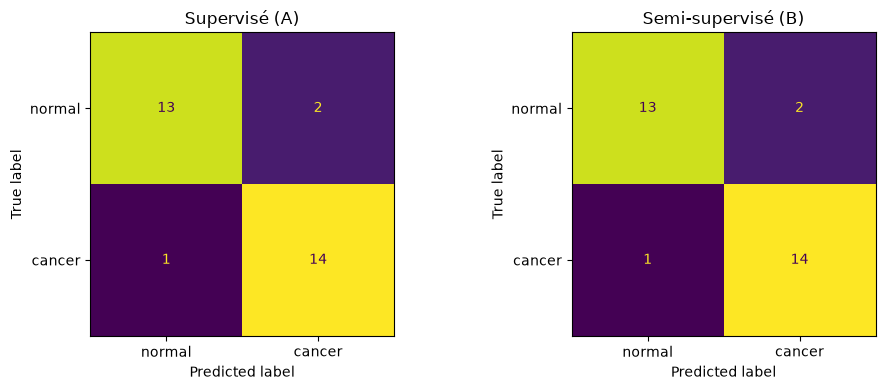

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(yA_vrai, yA_pred, display_labels=["normal","cancer"], ax=ax[0], colorbar=False)
ax[0].set_title("Supervisé (A)")
ConfusionMatrixDisplay.from_predictions(yB_vrai, yB_pred, display_labels=["normal","cancer"], ax=ax[1], colorbar=False)
ax[1].set_title("Semi-supervisé (B)")
fig.tight_layout()

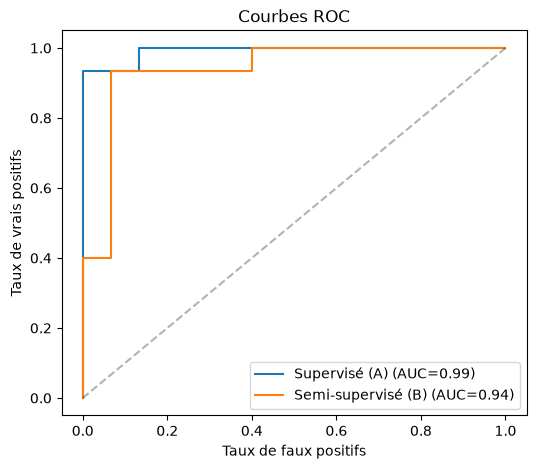

In [8]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(6, 5))
for nom, yv, yp in [("Supervisé (A)", yA_vrai, yA_proba), ("Semi-supervisé (B)", yB_vrai, yB_proba)]:
    fpr, tpr, _ = roc_curve(yv, yp)
    ax.plot(fpr, tpr, label=f"{nom} (AUC={roc_auc_score(yv, yp):.2f})")
ax.plot([0, 1], [0, 1], "k--", alpha=.3)
ax.set_xlabel("Taux de faux positifs"); ax.set_ylabel("Taux de vrais positifs")
ax.set_title("Courbes ROC"); ax.legend()

## 4.6 — Benchmarks additionnels

Le split CNN précédent répond à l'énoncé, mais il reste fragile : seulement 30 images de test. On ajoute donc deux contrôles :

1. des **baselines supervisées classiques** sur les embeddings ResNet50 du Notebook 1, évaluées en validation croisée répétée ;
2. des **features simples d'image** (luminosité, contraste, bordures, fond noir) pour mesurer le risque de raccourci non médical.

In [9]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import make_scorer, balanced_accuracy_score

features = np.load("../outputs/features_resnet50.npy")
cat = pd.read_csv("../outputs/catalogue_clean.csv")
mask_lab = cat["label"] != "inconnu"
X_embed = features[mask_lab.values]
y_embed = (cat.loc[mask_lab, "label"].values == "cancer").astype(int)

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
    "precision_cancer": make_scorer(precision_score, zero_division=0),
    "recall_cancer": make_scorer(recall_score, zero_division=0),
    "f1_cancer": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
}

modeles_supervises = {
    "Dummy most_frequent": DummyClassifier(strategy="most_frequent"),
    "LogReg L2": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, class_weight="balanced", random_state=0)),
    "PCA50 + LogReg": make_pipeline(StandardScaler(), PCA(n_components=50, random_state=0), LogisticRegression(max_iter=5000, class_weight="balanced", random_state=0)),
    "RBF SVM": make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1, gamma="scale", class_weight="balanced")),
    "kNN k=5": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "RandomForest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=0),
}

lignes = []
for nom, modele in modeles_supervises.items():
    res = cross_validate(modele, X_embed, y_embed, cv=cv, scoring=scoring, n_jobs=1, error_score="raise")
    ligne = {"modèle": nom}
    for k, v in res.items():
        if k.startswith("test_"):
            metrique = k.replace("test_", "")
            ligne[f"{metrique}_moy"] = v.mean()
            ligne[f"{metrique}_std"] = v.std()
    lignes.append(ligne)

benchmark_supervise = pd.DataFrame(lignes).sort_values("roc_auc_moy", ascending=False)
benchmark_supervise[["modèle", "accuracy_moy", "accuracy_std", "balanced_accuracy_moy",
                      "recall_cancer_moy", "precision_cancer_moy", "f1_cancer_moy",
                      "roc_auc_moy", "roc_auc_std"]].round(3)

,modèle,accuracy_moy,accuracy_std,balanced_accuracy_moy,recall_cancer_moy,precision_cancer_moy,f1_cancer_moy,roc_auc_moy,roc_auc_std
5,RandomForest,0.914,0.068,0.915,0.896,0.935,0.912,0.958,0.037
2,PCA50 + LogReg,0.894,0.066,0.894,0.900,0.898,0.895,0.950,0.049
1,LogReg L2,0.907,0.068,0.907,0.900,0.917,0.905,0.947,0.054
3,RBF SVM,0.839,0.067,0.837,0.960,0.781,0.860,0.927,0.051
4,kNN k=5,0.782,0.086,0.786,0.592,0.970,0.720,0.883,0.081
0,Dummy most_frequent,0.511,0.013,0.500,1.000,0.511,0.676,0.500,0.000


In [10]:
import cv2

def chemin_existant(p):
    chemin = Path(p)
    if chemin.exists():
        return chemin
    # Les CSV sont écrits depuis notebooks/ avec des chemins ../data ; utile si on exécute depuis la racine.
    if str(p).startswith("../"):
        return Path(str(p)[3:])
    return chemin

def stats_image(chemin):
    arr = np.array(Image.open(chemin_existant(chemin)).convert("L"), dtype=np.float32)
    h, w = arr.shape
    bord = 32
    masque_bord = np.zeros_like(arr, dtype=bool)
    masque_bord[:bord, :] = True; masque_bord[-bord:, :] = True
    masque_bord[:, :bord] = True; masque_bord[:, -bord:] = True
    centre = arr[h//4:3*h//4, w//4:3*w//4]
    return pd.Series({
        "moy": arr.mean(),
        "contraste": arr.std(),
        "p_noir": (arr < 10).mean(),
        "nettete": cv2.Laplacian(arr.astype(np.uint8), cv2.CV_64F).var(),
        "moy_bord": arr[masque_bord].mean(),
        "p_noir_bord": (arr[masque_bord] < 10).mean(),
        "moy_centre": centre.mean(),
        "contraste_centre": centre.std(),
    })

stats_lab = fort["chemin"].apply(stats_image)
y_stats = (fort["label"].values == "cancer").astype(int)

jeux_features = {
    "stats globales": ["moy", "contraste", "p_noir"],
    "bordures seules": ["moy_bord", "p_noir_bord"],
    "centre seul": ["moy_centre", "contraste_centre"],
    "toutes stats simples": list(stats_lab.columns),
}

lignes = []
for nom_features, colonnes in jeux_features.items():
    for nom_modele, modele in {
        "LogReg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced", random_state=0)),
        "RandomForest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=0),
    }.items():
        res = cross_validate(modele, stats_lab[colonnes], y_stats, cv=cv, scoring=scoring, n_jobs=1, error_score="raise")
        ligne = {"features": nom_features, "modèle": nom_modele}
        for k, v in res.items():
            if k.startswith("test_"):
                metrique = k.replace("test_", "")
                ligne[f"{metrique}_moy"] = v.mean()
                ligne[f"{metrique}_std"] = v.std()
        lignes.append(ligne)

benchmark_stats = pd.DataFrame(lignes).sort_values("roc_auc_moy", ascending=False)
benchmark_stats[["features", "modèle", "accuracy_moy", "accuracy_std", "balanced_accuracy_moy",
                 "recall_cancer_moy", "precision_cancer_moy", "f1_cancer_moy",
                 "roc_auc_moy", "roc_auc_std"]].round(3)

,features,modèle,accuracy_moy,accuracy_std,balanced_accuracy_moy,recall_cancer_moy,precision_cancer_moy,f1_cancer_moy,roc_auc_moy,roc_auc_std
7,toutes stats simples,RandomForest,0.845,0.072,0.844,0.852,0.850,0.847,0.917,0.060
6,toutes stats simples,LogReg,0.817,0.075,0.814,0.896,0.781,0.832,0.831,0.091
0,stats globales,LogReg,0.802,0.075,0.800,0.876,0.772,0.818,0.826,0.090
5,centre seul,RandomForest,0.767,0.084,0.766,0.764,0.785,0.769,0.815,0.071
1,stats globales,RandomForest,0.757,0.079,0.755,0.788,0.752,0.766,0.814,0.103
3,bordures seules,RandomForest,0.692,0.103,0.692,0.696,0.717,0.697,0.781,0.074
4,centre seul,LogReg,0.743,0.069,0.740,0.816,0.722,0.762,0.773,0.091
2,bordures seules,LogReg,0.589,0.097,0.584,0.788,0.568,0.657,0.575,0.110


## 4.7 — Stabilité supervisé vs semi-supervisé

Pour éviter de sur-interpréter un seul split, on répète la comparaison CNN sur **3 découpages stratifiés**. Pour garder le notebook relançable, cette boucle de stabilité utilise 3 epochs par étape au lieu de 5 ; le split principal ci-dessus reste l'expérience complète. Le protocole reste identique : modèle A entraîné sur le fort seulement, modèle B pré-entraîné sur les pseudo-labels puis affiné sur le fort.

In [11]:
def construire_loader(df_source, col_label, tf, batch_size, shuffle, seed):
    generateur = torch.Generator()
    generateur.manual_seed(seed)
    return DataLoader(
        IRMDataset(df_source, col_label, tf),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=2,
        generator=generateur if shuffle else None,
    )

def evaluer_split(seed, epochs=3):
    fixer_seed(seed)
    train_split, test_split = train_test_split(
        fort, test_size=0.3, stratify=fort["label"], random_state=seed)

    loader_train = construire_loader(train_split, "label", tf_train, 16, True, seed)
    loader_test_split = construire_loader(test_split, "label", tf_eval, 16, False, seed)
    loader_faible_split = construire_loader(faible, "pseudo_label", tf_train, 32, True, seed)

    model_a = entrainer(nouveau_modele(), loader_train, epochs=epochs, lr=1e-4, verbose=False)
    yv, yp, yproba = evaluer(model_a, loader_test_split)
    res_a = metriques(yv, yp, yproba)
    res_a.update({"seed": seed, "régime": "Supervisé"})

    fixer_seed(seed)
    model_b = nouveau_modele()
    model_b = entrainer(model_b, loader_faible_split, epochs=epochs, lr=1e-4, verbose=False)
    model_b = entrainer(model_b, loader_train, epochs=epochs, lr=1e-4, verbose=False)
    yv, yp, yproba = evaluer(model_b, loader_test_split)
    res_b = metriques(yv, yp, yproba)
    res_b.update({"seed": seed, "régime": "Semi-supervisé"})
    return res_a, res_b

resultats = []
for seed in [0, 1, 2]:
    print("Split seed", seed)
    resultats.extend(evaluer_split(seed, epochs=3))

resultats_repetes = pd.DataFrame(resultats)
resume_repetes = resultats_repetes.groupby("régime")[["accuracy", "precision", "recall (cancer)", "F1", "ROC-AUC"]].agg(["mean", "std"])
resume_repetes.round(3)

Split seed 0


Split seed 1


Split seed 2


accuracy        precision        recall (cancer)            F1  \
                   mean    std      mean    std            mean    std   mean   
régime                                                                          
Semi-supervisé    0.867  0.058     0.839  0.112           0.933  0.067  0.878   
Supervisé         0.911  0.019     0.912  0.032           0.911  0.038  0.911   

                      ROC-AUC         
                  std    mean    std  
régime                                
Semi-supervisé  0.039    0.95  0.037  
Supervisé       0.020    0.97  0.019

### Lecture des résultats

Sur le split principal, les deux modèles détectent autant de cancers : le **recall cancer est identique**. Le semi-supervisé reste légèrement inférieur sur la précision, le F1 et l'AUC. Comme le test ne compte qu'une trentaine d'images, ce résultat seul ne suffit pas à conclure fortement.

Les benchmarks additionnels apportent trois enseignements :

1. Des modèles classiques entraînés sur les embeddings ResNet50 sont déjà compétitifs. Cela confirme que le transfer learning extrait un signal exploitable même avec peu de labels.
2. Des features très simples (luminosité, contraste, bordures, fond noir) obtiennent aussi des scores non négligeables. C'est un signal de vigilance : une partie de la performance peut venir de raccourcis liés au protocole d'acquisition ou au cadrage.
3. La comparaison répétée supervisé / semi-supervisé est plus honnête qu'un unique split : si le semi-supervisé ne domine pas clairement en moyenne, il ne faut pas le vendre comme un gain établi.

> **Conclusion technique :** les pseudo-labels benchmarkés peuvent aider à structurer une expérimentation, mais ils ne remplacent pas des labels experts. La priorité métier reste d'investir dans une annotation ciblée et dans une validation robuste.

## 4.8 — Conclusion et lien métier

**Definition of done (objectif atteint) :** un modèle de détection est satisfaisant s'il **maximise le recall sur le cancer** (ne pas rater de tumeur) tout en gardant une précision raisonnable. Sur le split principal, le supervisé atteint un recall cancer élevé ; la validation répétée sert à vérifier que ce constat n'est pas uniquement un accident de split.

**Verdict supervisé vs semi-supervisé :** l'approche semi-supervisée ne doit pas être présentée comme supérieure par défaut. Après benchmark du clustering, les pseudo-labels sont plus défendables qu'avec K-Means seul, mais leur valeur doit être mesurée sur plusieurs splits. Si le gain moyen n'est pas net, la conclusion correcte est : **le semi-supervisé est expérimental, pas encore un levier prouvé de performance**.

**Limites :**
- Jeu fortement labellisé très petit → métriques instables, même en répétant les splits.
- Risque de raccourci lié aux différences globales d'intensité/cadrage, confirmé par les baselines sur features simples.
- Pseudo-labels issus d'un clustering : utiles pour explorer, insuffisants comme vérité terrain.

**Implication métier :** pour 4 millions d'images et 5 000 €, il vaut mieux combiner transfer learning, active learning, annotation experte ciblée, calibration du seuil sur le recall et validation clinique, plutôt que compter sur un clustering automatique seul.

**Definition of done — Notebook 2 :** jeu de test stratifié et jamais vu · 2 régimes entraînés · métriques orientées faux négatif · baselines supervisées · contrôle des raccourcis · comparaison répétée et limites explicitées.

*Fin du Notebook 2.*